In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Clean the TotalCharges column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Show the first few rows to confirm it works
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check for missing values (especially important after your TotalCharges cleaning)
print("Missing values per column:\n", df.isnull().sum())

# Calculate the average customer tenure
print(f"\nAverage customer tenure: {df['tenure'].mean():.2f} months")

# Check the distribution of the target variable 'Churn'
print("\nChurn distribution:\n", df['Churn'].value_counts(normalize=True))

Missing values per column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Average customer tenure: 32.37 months

Churn distribution:
 Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [3]:
# Convert 'Churn' to numeric (1 for Yes, 0 for No) to calculate average churn rate
df['Churn_numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Group by Contract type
contract_churn = df.groupby('Contract')['Churn_numeric'].mean() * 100
print("Churn Rate by Contract Type (%):\n", contract_churn)

# Group by Internet Service
internet_churn = df.groupby('InternetService')['Churn_numeric'].mean() * 100
print("\nChurn Rate by Internet Service (%):\n", internet_churn)

Churn Rate by Contract Type (%):
 Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_numeric, dtype: float64

Churn Rate by Internet Service (%):
 InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn_numeric, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_6980\4248946427.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contract', y='Churn_numeric', data=df, errorbar=None, palette='viridis')


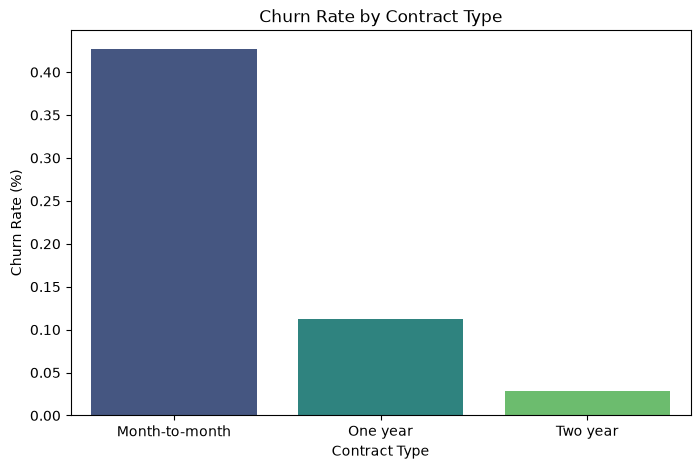

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Contract', y='Churn_numeric', data=df, errorbar=None, palette='viridis')

# Add labels
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.show()